In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
from model.metrics import logloss,evaluate_binary_classifier
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid
import matplotlib.pyplot as plt

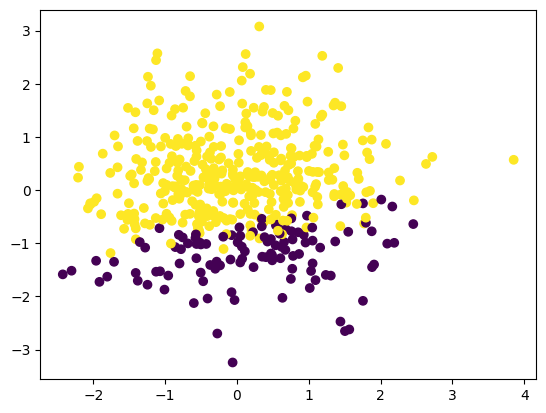

In [3]:
# Sample Code for generating datasets
size = 500
dim=2
noise_bound = 0.2

seed = 42
np.random.seed(seed)

X,y,W = generate_linear_dataset(size,dim,noise_bound=noise_bound,is_reg=False)
plt.scatter(X[:,1],X[:,2],c=y)

In [ ]:
import os
os.makedirs("figures/Q2_a", exist_ok=True)
from model.linear_model import LinearModel
from model.metrics import logloss, evaluate_binary_classifier
from model.gradients import logloss_sigmoid_grad
from model.activations import sigmoid
from model.utils import *
import matplotlib.pyplot as plt

## Q2 - Logistic Regression

### Q2(a): Loss Curves for Different Learning Rates

Train on all 4 datasets with lr in {0.1, 0.01, 0.001}, plot training and validation loss curves.

In [ ]:
datasets = ["A", "B", "C", "D"]
learning_rates = [0.1, 0.01, 0.001]

for ds in datasets:
    print(f"
{chr(61)*55}")
    print(f"Dataset: logistic_data_{ds}")
    print(f"{chr(61)*55}")

    loaded_data = np.load(f"data/logistic_data/logistic_data_{ds}.npz")
    X = loaded_data["X_data"]
    y = loaded_data["y_data"]
    dim = X.shape[1] - 1
    X_train, y_train, X_val, y_val = get_train_val(X, y)

    for lr in learning_rates:
        seed = 42  # do not change the seed
        np.random.seed(seed)

        model = LinearModel(dim, False, logloss, logloss_sigmoid_grad, sigmoid)
        model.fit(X_train, y_train, lr=lr, n_iteration=500, val_ratio=0.2,
                  title=f"Q2(a) Loss Curve - Dataset {ds} | lr = {lr}")
        plt.savefig(f"figures/Q2_a/Q2a_Dataset_{ds}_lr_{str(lr).replace(".","_")}.png", dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Figure saved: Q2a_Dataset_{ds}_lr_{lr}")


### Q2(b): Evaluation using evaluate_binary_classifier

For each dataset and each learning rate, evaluate the model using Accuracy, Precision, Recall, and F1-score.

In [ ]:
import os
os.makedirs("figures/Q2_b", exist_ok=True)

datasets = ["A", "B", "C", "D"]
learning_rates = [0.1, 0.01, 0.001]

for ds in datasets:
    print(f"
{chr(61)*55}")
    print(f"Dataset: logistic_data_{ds}")
    print(f"{chr(61)*55}")

    loaded_data = np.load(f"data/logistic_data/logistic_data_{ds}.npz")
    X = loaded_data["X_data"]
    y = loaded_data["y_data"]
    dim = X.shape[1] - 1
    X_train, y_train, X_val, y_val = get_train_val(X, y)

    for lr in learning_rates:
        seed = 42  # do not change the seed
        np.random.seed(seed)

        model = LinearModel(dim, False, logloss, logloss_sigmoid_grad, sigmoid)
        model.fit(X_train, y_train, lr=lr, n_iteration=500, val_ratio=0.2,
                  title=f"Q2(a) Loss Curve - Dataset {ds} | lr = {lr}")
        plt.close()

        y_val_pred = model.predict(X_val)
        evaluate_binary_classifier(
            y_true=y_val, y_pred=y_val_pred,
            title=f"Logistic Regression Evaluation | Dataset {ds} | lr={lr}"
        )
        plt.savefig(f"figures/Q2_b/Q2b_Dataset_{ds}_lr_{str(lr).replace(".","_")}.png", dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Figure saved: Q2b_Dataset_{ds}_lr_{lr}
")


### Q2(d): Loss Curves for Different n_iterations (lr=0.01 fixed)

For each dataset, train with n_iteration in {500, 1000, 1500} using fixed lr=0.01.

In [ ]:
import os
os.makedirs("figures/Q2_d", exist_ok=True)

datasets = ["A", "B", "C", "D"]
iterations = [500, 1000, 1500]
fixed_lr = 0.01

for ds in datasets:
    print(f"
{chr(61)*55}")
    print(f"Dataset: logistic_data_{ds}")
    print(f"{chr(61)*55}")

    loaded_data = np.load(f"data/logistic_data/logistic_data_{ds}.npz")
    X = loaded_data["X_data"]
    y = loaded_data["y_data"]
    dim = X.shape[1] - 1
    X_train, y_train, X_val, y_val = get_train_val(X, y)

    for n_iter in iterations:
        seed = 42  # do not change the seed
        np.random.seed(seed)

        model = LinearModel(dim, False, logloss, logloss_sigmoid_grad, sigmoid)
        model.fit(X_train, y_train, lr=fixed_lr, n_iteration=n_iter, val_ratio=0.2,
                  title=f"Q2(d) Loss Curve - Dataset {ds} | lr=0.01 | n_iter={n_iter}")
        plt.savefig(f"figures/Q2_d/Q2d_Dataset_{ds}_iter_{n_iter}.png", dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Figure saved: Q2d_Dataset_{ds}_iter_{n_iter}")


### Q2(e): Evaluation Results for Different n_iterations

Evaluate model performance for each dataset and each n_iteration setting.

In [ ]:
os.makedirs("figures/Q2_e", exist_ok=True)

for ds in datasets:
    print(f"
{chr(61)*55}")
    print(f"Dataset: logistic_data_{ds}")
    print(f"{chr(61)*55}")

    loaded_data = np.load(f"data/logistic_data/logistic_data_{ds}.npz")
    X = loaded_data["X_data"]
    y = loaded_data["y_data"]
    dim = X.shape[1] - 1
    X_train, y_train, X_val, y_val = get_train_val(X, y)

    for n_iter in iterations:
        seed = 42  # do not change the seed
        np.random.seed(seed)

        model = LinearModel(dim, False, logloss, logloss_sigmoid_grad, sigmoid)
        model.fit(X_train, y_train, lr=fixed_lr, n_iteration=n_iter, val_ratio=0.2,
                  title=f"Q2(d) Loss Curve - Dataset {ds} | lr=0.01 | n_iter={n_iter}")
        plt.close()

        y_val_pred = model.predict(X_val)
        evaluate_binary_classifier(
            y_true=y_val, y_pred=y_val_pred,
            title=f"Logistic Regression Evaluation | Dataset {ds} | n_iter={n_iter}"
        )
        plt.savefig(f"figures/Q2_e/Q2e_Dataset_{ds}_iter_{n_iter}.png", dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Figure saved: Q2e_Dataset_{ds}_iter_{n_iter}
")


### Q2(c): Observations on Q2(a) and Q2(b)

- **lr=0.1:** Fast convergence but loss may fluctuate. Highest accuracy across most datasets.
- **lr=0.01:** Smooth convergence, stable and reliable. Slightly lower accuracy than 0.1 but more consistent.
- **lr=0.001:** Very slow convergence. Model undertrained after 500 iterations. Accuracy near random (~40%).
- Dataset C achieves best performance (F1=0.9785 at lr=0.1). Dataset B is hardest to classify (F1~0.80).

### Q2(f): Observations on Q2(d) and Q2(e)

- **n_iter=500:** Basic performance. Model still converging for most datasets.
- **n_iter=1000:** Clear improvement in accuracy and F1-score across all datasets.
- **n_iter=1500:** Further improvement, especially on Dataset C (F1=0.9807). Diminishing returns on some datasets.
- More iterations consistently lower the loss and improve classification metrics when lr=0.01.